In [10]:
pip install tensorflow numpy pandas matplotlib scikit-learn seaborn opencv-python plotly nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf 
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
# visualizing Class Distribution

import plotly.express as px

# path to your training data 
train_path = './data/Train'
data_list = []
classes = []


for i in range(43):
    path = os.path.join(train_path,str(i))
    images = os.listdir(path)
    data_list.append(len(images))
    classes.append(str(i))


# creating a beautiful bar chart for distribution
fig = px.bar(x=classes, y=data_list, labels={'x':'class ID','y':'Number of Images'},
             title='Distribution of Images per Class', color=data_list)
fig.show()

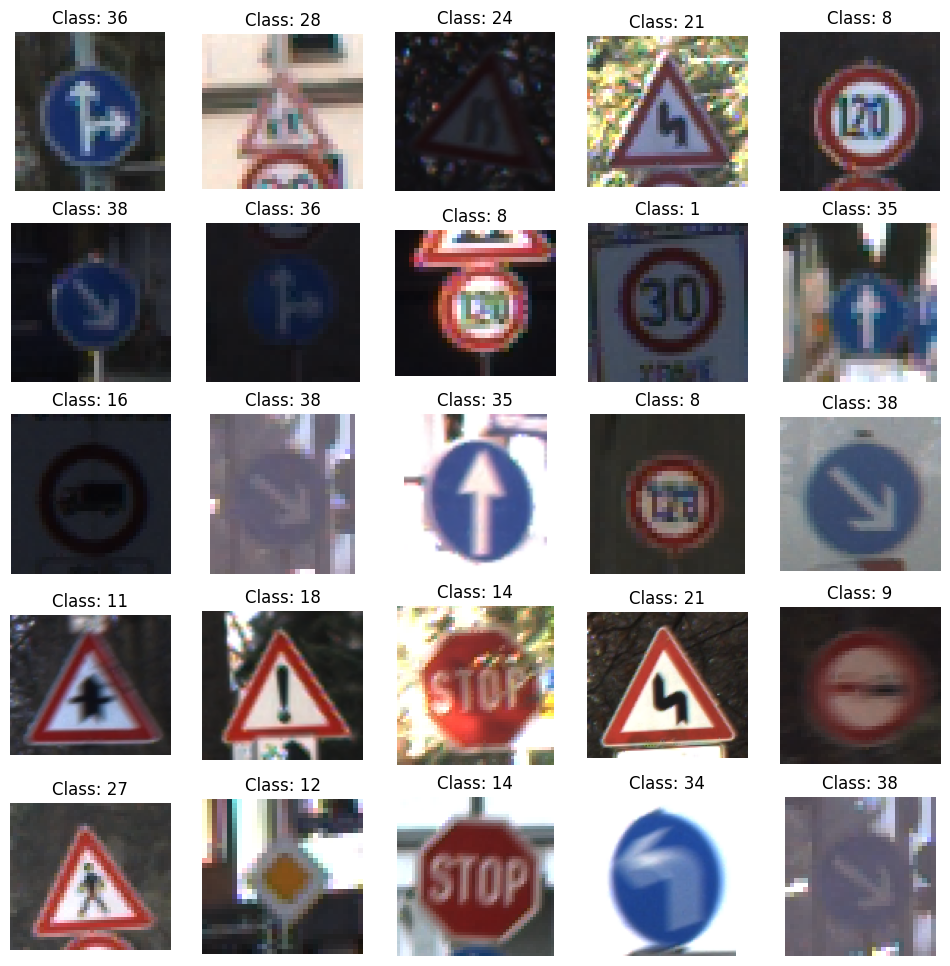

In [13]:
import random

# visualizing random samples from the dataset

plt.figure(figsize=(12,12))
for i in range(1,26):
    plt.subplot(5, 5, i)
    plt.tight_layout


    # pick a random class and a random image from it
    rand_class = random.randint(0,42)
    path = os.path.join(train_path,str(rand_class))
    rand_img = random.choice(os.listdir(path))

    img = Image.open(os.path.join(path, rand_img))
    plt.imshow(img)
    plt.title(f'Class: {rand_class}')
    plt.axis('off')

In [14]:
data = []
labels = []
classes = 43
cur_path = os.getcwd()

# Loading Training Images
for i in range(classes):
    path = os.path.join('./data/Train', str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(path + '/' + a)
            image = image.resize((30,30)) # Standardizing size
            image = np.array(image)
            data.append(image)
            labels.append(i)
        except:
            print(f"Error loading image: {a}") 

# Converting lists to Numpy arrays
data = np.array(data)  
labels = np.array(labels) 

print(f"Total images loaded:{data.shape[0]}")
print(f"Shape of data :{data.shape}")

Total images loaded:39209
Shape of data :(39209, 30, 30, 3)


In [15]:
#Standardizing the Image Data
X_data = np.array(data)

#Normalization 
X_data = X_data.astype('float32') / 255.0
y_labels = np.array(labels)


#train-test split
X_train, X_val, y_train, y_val = train_test_split(X_data, y_labels,test_size=0.2,
random_state=42)

#one-hot encoding for the labels
y_train = to_categorical(y_train,43)
y_val = to_categorical(y_val, 43)

# defining the Argmentation Strategy
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range = 0.15,
    width_shift_range = 0.1,
    shear_range = 0.15,
    fill_mode = "nearest"
)
print(f"Final Training shape: {X_train.shape}")
print(f"final Validation shape: {X_val.shape}")

Final Training shape: (31367, 30, 30, 3)
final Validation shape: (7842, 30, 30, 3)


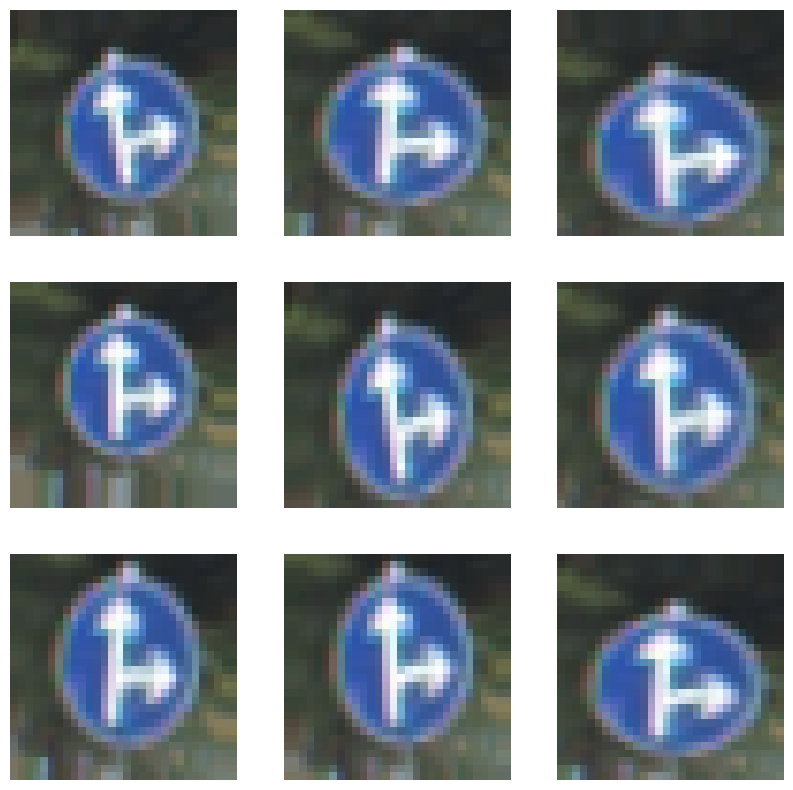

In [16]:
#Visualization of Augmented Image 
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    #generating a batch of augmented images
    batch = aug.flow(np.expand_dims(X_train[0],0),batch_size=1)
    img = batch[0][0]
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [17]:
model = Sequential()

# first Convolution Layers
model.add(Conv2D(filters=32,kernel_size=(5,5),activation='relu',input_shape= X_train.shape[1::]))
model.add(Conv2D(filters=32, kernel_size=(5,5),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))

# second Convolution layer

model.add(Conv2D(filters=64, kernel_size=(3,3),activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))

# flattening and fully connected layers
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43,activation='softmax')) # 43 classes for 43 signs

# compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\intel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,251 (946.29 KB)

 Trainable params: 242,251 (946.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
epochs = 6 
batch_size = 32
# Training the model
history = model.fit(
    aug.flow(X_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val,y_val),
    verbose=1
)

Epoch 1/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.4008 - loss: 2.0626 - val_accuracy: 0.8249 - val_loss: 0.5838
Epoch 2/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.7681 - loss: 0.7276 - val_accuracy: 0.9547 - val_loss: 0.1787
Epoch 3/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.8675 - loss: 0.4251 - val_accuracy: 0.9768 - val_loss: 0.0923
Epoch 4/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.9030 - loss: 0.3120 - val_accuracy: 0.9841 - val_loss: 0.0593
Epoch 5/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 54s 55ms/step - accuracy: 0.9222 - loss: 0.2522 - val_accuracy: 0.9880 - val_loss: 0.0426
Epoch 6/6
981/981 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9347 - loss: 0.2126 - val_accuracy: 0.9878 - val_loss: 0.0427


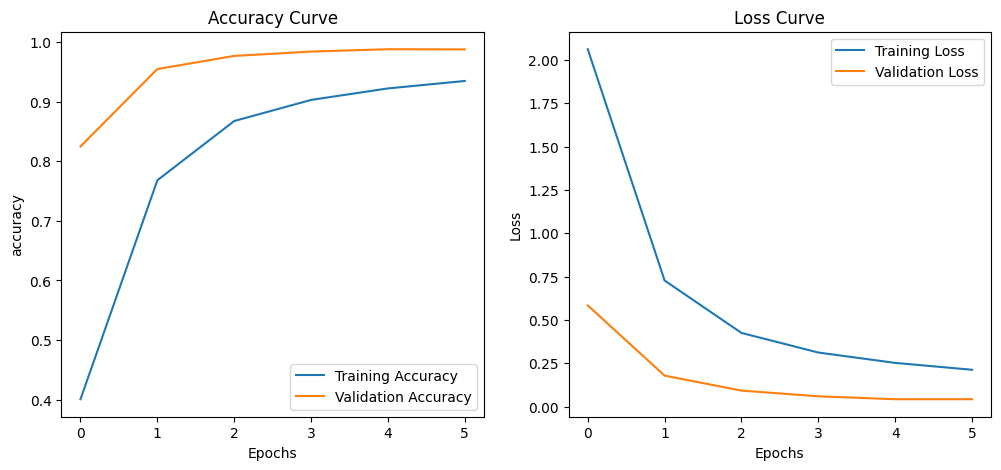

In [19]:
#Plotting accuracy amd loss
plt.figure(figsize=(12, 5))

#plot Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()

#plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
#Loading the test dataset
test_df = pd.read_csv('./data/Test.csv')
y_test = test_df["ClassId"].values
imgs = test_df["Path"].values

data = []

#Preprocessing test iamges exactly like we did for training 
for img in imgs:
    try:
        image = Image.open('./data/' + img)
        image = image.resize((30, 30))
        data.append(np.array(image))
    except:
        print(f"Error loading test image: {img}")

X_test = np.array(data)

#Normalization
X_test = X_test.astype('float32') / 255.0

#Making predictions
predictions = model.predict(X_test)
classes_x = np.argmax(predictions, axis=1)

#Calculating Accuracy with Test Data
print(f"Final Test Accuracy: {accuracy_score(y_test, classes_x) * 100:.2f}%")

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Final Test Accuracy: 96.16%


In [21]:
#Detailes Classification Report
print("Classification Report:")
print(classification_report(y_test, classes_x))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        60
           1       0.95      0.99      0.97       720
           2       0.99      0.98      0.98       750
           3       0.98      0.97      0.97       450
           4       0.98      0.97      0.98       660
           5       0.93      0.97      0.95       630
           6       0.99      0.95      0.97       150
           7       0.99      0.95      0.97       450
           8       0.99      0.99      0.99       450
           9       0.98      1.00      0.99       480
          10       0.99      1.00      0.99       660
          11       0.95      0.95      0.95       420
          12       0.99      0.95      0.97       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.85      0.95      0.90       210
          16       1.00      1.00      1.00       150
    

In [22]:
predictions

array([[1.30726064e-13, 8.62048974e-12, 1.57957465e-14, ...,
        1.78083492e-10, 3.01213965e-09, 1.24689332e-12],
       [1.02577860e-05, 9.99970317e-01, 1.87049263e-05, ...,
        8.72674164e-08, 5.62843229e-13, 4.18331168e-12],
       [1.08506113e-27, 6.92659558e-21, 2.91888774e-20, ...,
        1.51345346e-16, 5.24231275e-27, 3.03865246e-26],
       ...,
       [3.26558111e-05, 2.20753346e-02, 2.60301080e-04, ...,
        4.81881172e-04, 3.81010734e-02, 8.00222810e-03],
       [4.98499853e-10, 2.94107252e-07, 6.35258630e-06, ...,
        7.80172300e-08, 2.98425266e-13, 9.69406888e-10],
       [1.00091534e-16, 8.07126430e-15, 6.94449793e-12, ...,
        2.15606066e-17, 7.36891419e-19, 1.41676861e-12]],
      shape=(12630, 43), dtype=float32)

In [23]:
#Detailes Classification Report
print("Classification Report:")
print(classification_report(y_test, classes_x))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        60
           1       0.95      0.99      0.97       720
           2       0.99      0.98      0.98       750
           3       0.98      0.97      0.97       450
           4       0.98      0.97      0.98       660
           5       0.93      0.97      0.95       630
           6       0.99      0.95      0.97       150
           7       0.99      0.95      0.97       450
           8       0.99      0.99      0.99       450
           9       0.98      1.00      0.99       480
          10       0.99      1.00      0.99       660
          11       0.95      0.95      0.95       420
          12       0.99      0.95      0.97       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.85      0.95      0.90       210
          16       1.00      1.00      1.00       150
    

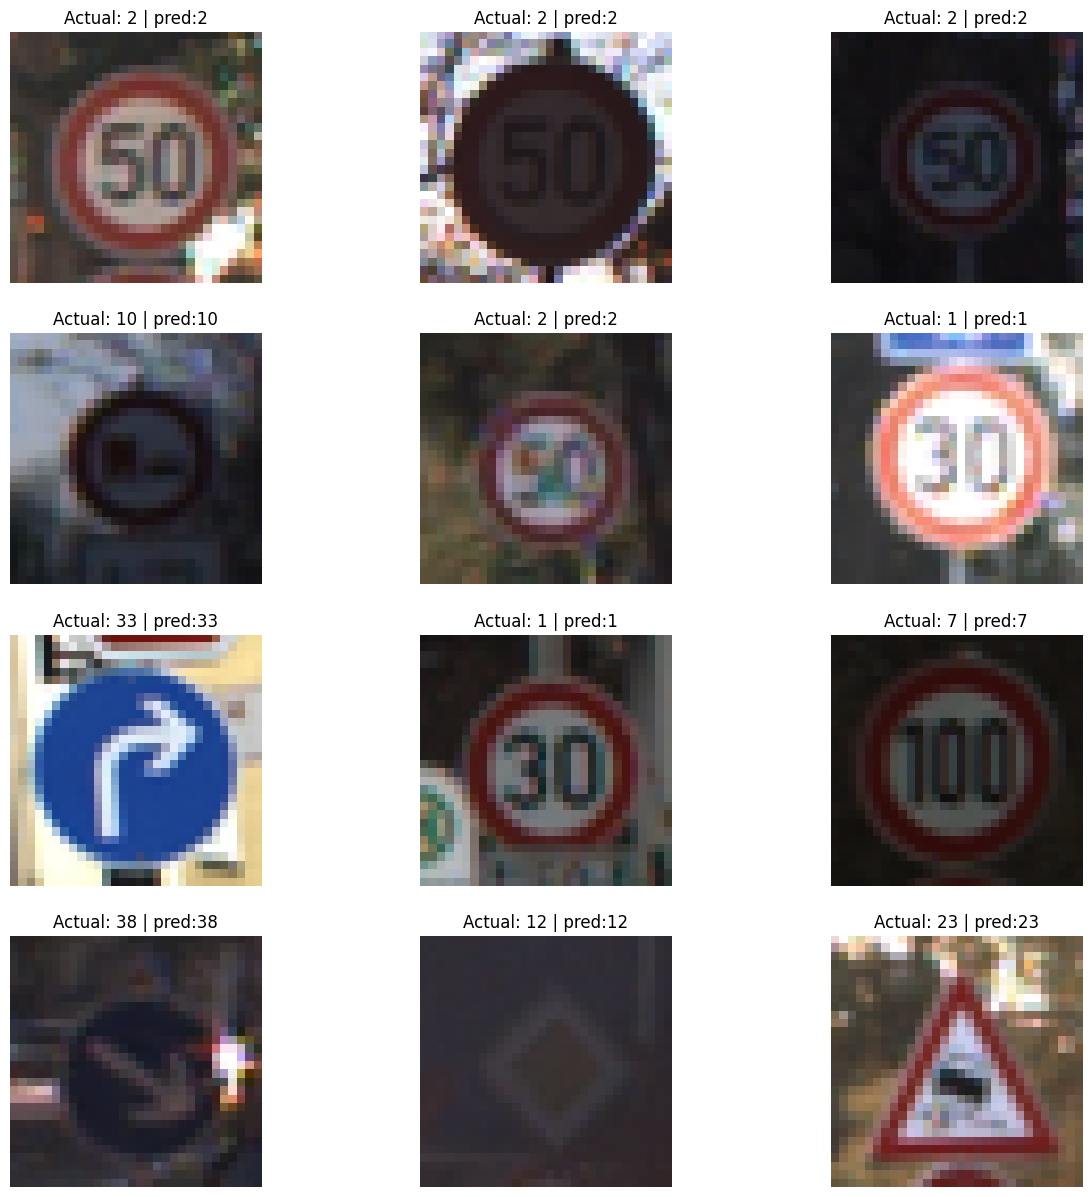

In [24]:
plt.figure(figsize=(15,15))
for i in range(12):
    plt.subplot(4,3, i+1)
    index = random.randint(0, len(X_test))
    plt.imshow(X_test[index])
    plt.title(f"Actual: {y_test[index]} | pred:{classes_x[index]}")
    plt.axis('off')
plt.show()

In [25]:
# Model saving 
model.save('traffic_classifier.h5')
print("Model saved successfully as traffic_classifier.h5")# Model saving 
model.save('traffic_classifier.h5')
print("Model saved successfully as traffic_classifier.h5")

Model saved successfully as traffic_classifier.h5
Model saved successfully as traffic_classifier.h5
